# **Expectation-Maximization (EM) for Poisson Mixture Model**

## 1. Objective
This notebook implements the **Expectation-Maximization (EM) algorithm** to estimate the parameters of a **Poisson Mixture Model**. The goal is to understand how EM can be used to uncover hidden subpopulations within count data generated from multiple Poisson distributions.

## 2. Dataset
We generate a **synthetic phone message dataset**, where each data point represents the daily number of messages sent by a user. The counts are drawn from a mixture of two **Poisson distributions**.

## 3. Key Questions
1. How can the EM algorithm be applied to accurately estimate the **Poisson rates (λ)** for each hidden group?
2. Does the EM algorithm converge to stable estimates when applied to count data?
3. How do visualizations help to understand the parameter updates and clustering behavior?

## 4. Technical Highlights
- Developed a complete implementation of the **EM algorithm** for a **Poisson Mixture Model**, including random initialization, E-step, M-step, and convergence checking.
- Generated synthetic data for two distinct user clusters based on different **Poisson parameters**.
- Visualized the changes in estimated parameters over iterations to demonstrate how EM converges to optimal solutions.
- Presented clear explanations of the mathematical steps involved, supported by visual aids.
- The entire analysis was conducted using **Python (Jupyter Notebook)** with libraries such as **numpy, matplotlib, and seaborn**.

## Part 1: Expectation-Maximization Algorithm for a Poisson Mixture Model

We will be implementing the Expectation-Maximization Algorithm for a **Poisson Mixture Model**, which is a probabilistic model that assumes that data is generated from a mixture of Poisson distributions, where each component represents a subpopulation with its own Poisson parameter.

A **Poisson distribution** models count data where the average rate is constant over time. A dataset follows a Poisson if you're counting how many times something happens, over a fixed interval, and each count is independent and discrete.

In our assignment, we will be generating synthetic **Phone Messages Data**. Let's assume that there are 2 types of phone users:
* Cluster 0 - Light Users or Digital Minimalists who send 8 messages a day on average
* Cluster 1 - Power Users or Phone Addicts who send 16 messages a day on average

Data points in both these clusters follow a Poisson distribution.

In [20]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from matplotlib.patches import Patch
from IPython.display import HTML
from sklearn.metrics import confusion_matrix
from PIL import Image

### Step 1.1: Generate Synthetic Message Data

In [21]:
# Assumption: 2 types of phone users - Light and Power users, wherein we count
# the Number of Messages per day per user, and the numbers follow a Poisson distribution
np.random.seed(42)

# Setup ground truth of Poisson rates
n_users_per_cluster = 20
days_per_user = 20

lambda_true = [8, 16]  # Light vs Power Users
n_clusters = len(lambda_true)
pi_true = [0.6, 0.4]  # Assume 60% probability for Light Users, 40% for Power Users

# Generate synthetic data
user_ids = []
message_counts = []
true_clusters = []

for cluster_id, lam in enumerate(lambda_true):
    for user in range(n_users_per_cluster):
        counts = np.random.poisson(lam=lam, size=days_per_user)
        uid = f"U{cluster_id * n_users_per_cluster + user + 1}"
        user_ids.extend([uid] * days_per_user)
        message_counts.extend(counts)
        true_clusters.extend([cluster_id] * days_per_user)

# Add outliers (1% of all data with extremely high counts)
n_outliers = int(0.01 * len(message_counts))
outlier_indices = np.random.choice(len(message_counts), size=n_outliers, replace=False)
for idx in outlier_indices:
    message_counts[idx] += np.random.randint(20, 30)

# Create dataframe
df_msgs = pd.DataFrame({
    "user_id": user_ids,
    "messages": message_counts,
    "true_cluster": true_clusters  # 0 for Light Users, 1 for Power Users
})

# Preview synthetic data
print("Sample message count data:")
print(f'Shape of dataset: {df_msgs.shape}')
df_msgs.sample(5)

Sample message count data:
Shape of dataset: (800, 3)


,user_id,messages,true_cluster
455,U23,17,1
591,U30,18,1
31,U2,9,0
156,U8,9,0
769,U39,15,1


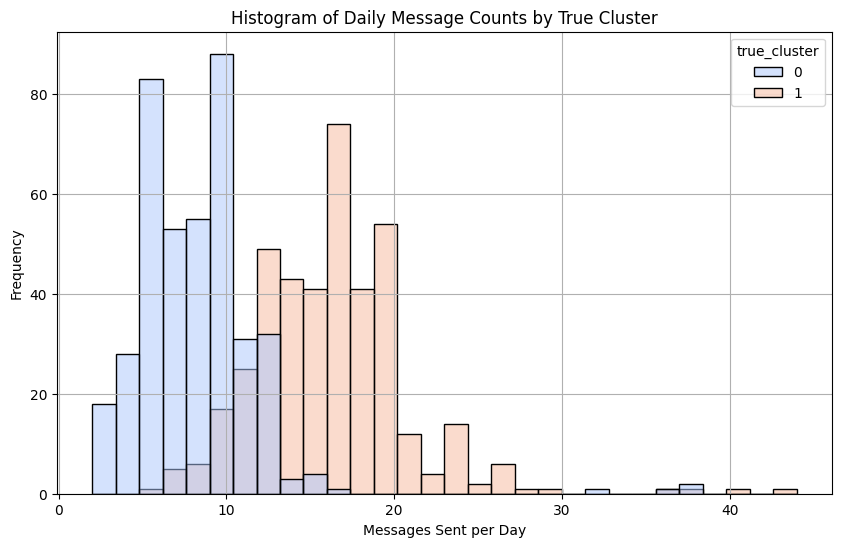

In [22]:
# Histogram of original synthetic message data
plt.figure(figsize=(10, 6))
sns.histplot(data=df_msgs, x="messages", hue="true_cluster", bins=30, kde=False, palette="coolwarm")
plt.title("Histogram of Daily Message Counts by True Cluster")
plt.xlabel("Messages Sent per Day")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

The chart highlights a **rather clear distinction** between power users and light users, with power users consistently sending a significantly higher number of messages compared to light users. Still, there is **noticeable overlap** in the messaging counts between these groups. Additionally, the presence of a few outlier points adds complexity, obscuring the boundaries between the two user segments.

Next, we review the messages sent by different users.

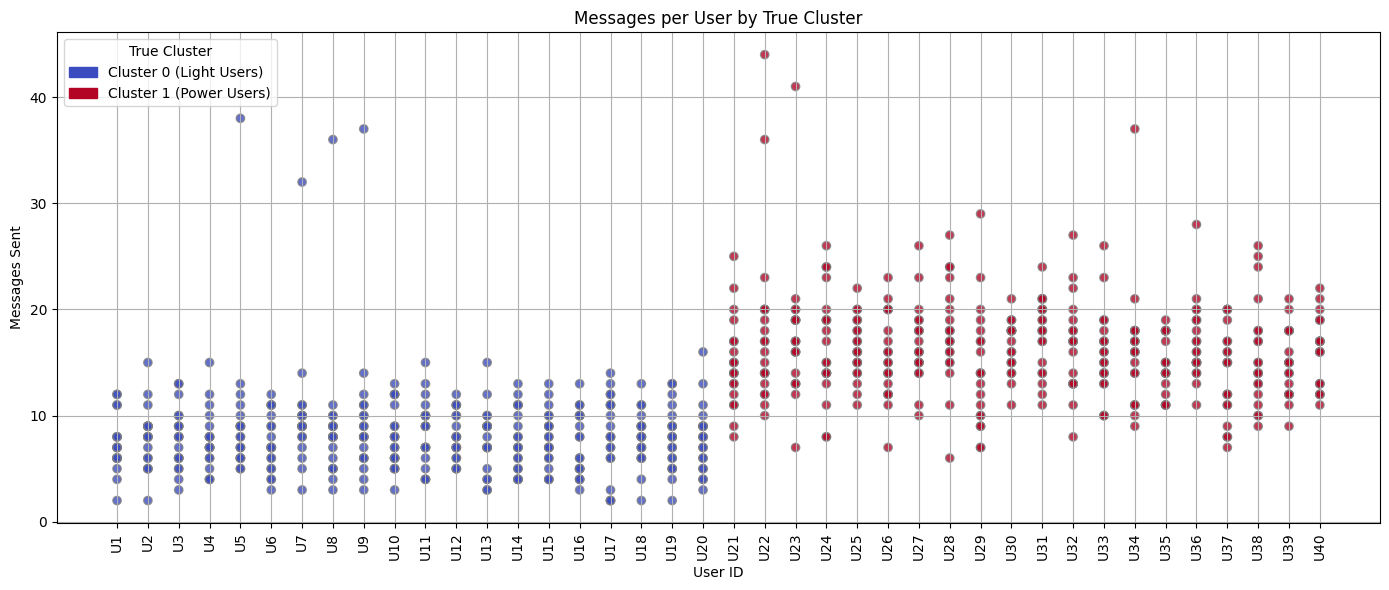

In [23]:
# Scatter plot of synthetic data
cmap = plt.colormaps.get_cmap('coolwarm')
dark_colors = [cmap(0.0), cmap(1.0)] 

# Map true_cluster values to colors
cluster_colors = df_msgs['true_cluster'].map({0: dark_colors[0], 1: dark_colors[1]})

plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    x=df_msgs['user_id'],
    y=df_msgs['messages'],  # Each point = messages sent in 1 day
    c=cluster_colors,
    alpha=0.8,
    edgecolor='gray'
)

plt.xticks(rotation=90)
plt.title("Messages per User by True Cluster")
plt.xlabel("User ID")
plt.ylabel("Messages Sent")

legend_handles = [
    Patch(color=dark_colors[0], label='Cluster 0 (Light Users)'),
    Patch(color=dark_colors[1], label='Cluster 1 (Power Users)')
]
plt.legend(handles=legend_handles, title="True Cluster", loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()


### Step 1.2: Implement Expectation-Maximization Algorithm for Poisson Mixture Model

We apply the Expectation-Maximization (EM) algorithm to fit a Poisson Mixture Model to count data (e.g., the number of messages sent per day).

**Let:**
- $x_i$ be the number of messages for observation $i$
- $K$ be the number of mixture components (clusters)
- $\lambda_k$ be the Poisson rate parameter for cluster $k$
- $\pi_k$ be the mixing proportion (prior probability) of cluster $k$
- $\gamma_{ik}$ be the posterior probability that $x_i$ belongs to cluster $k$.

---

#### E-Step: Compute Responsibilities

For each data point $x_i$, compute the soft assignment (responsibility) for each cluster $k$:

For each $i$ and $k$, we have
$\gamma_{ik} = \frac{\pi_k \cdot \text{Poisson}(x_i \mid \lambda_k)}{\sum_{j=1}^K \pi_j \cdot \text{Poisson}(x_i \mid \lambda_j)}$,
  
where the Poisson probability mass function is
$\text{Poisson}(x_i \mid \lambda_k) = \frac{\lambda_k^{x_i} e^{-\lambda_k}}{x_i!}$.

---

#### M-Step: Update Parameters

Update the parameters using the responsibilities $\gamma_{ik}$:

- **Mixing Coefficients:** $\pi_k^{\text{new}} = \frac{1}{N} \sum_{i=1}^N \gamma_{ik}$.
- **Poisson Rates:** $\lambda_k^{\text{new}} = \frac{\sum_{i=1}^N \gamma_{ik} x_i}{\sum_{i=1}^N \gamma_{ik}}$.

---

Repeat the E-step and M-step until convergence (e.g., when the change in log-likelihood is smaller than a predefined threshold).


In [24]:
# Store soft assignments per iteration
gamma_history = []

# Define the function for EM
def em_poisson_mixture(data, K=2, max_iter=100, tol=1e-4, verbose=True):
    N = len(data)

    # Initialize parameters
    pi = np.ones(K) / K
    lambdas = np.sort(np.random.uniform(6, 14, K))  # Sorted to make cluster 0 < cluster 1
    gamma = np.zeros((N, K))

    log_likelihoods = []

    for iteration in range(max_iter):
        # E-step
        for k in range(K):
            gamma[:, k] = pi[k] * poisson.pmf(data, mu=lambdas[k])
        gamma_sum = np.sum(gamma, axis=1, keepdims=True)
        gamma /= gamma_sum

        # M-step
        Nk = gamma.sum(axis=0)
        pi = Nk / N
        lambdas = np.sum(gamma * data[:, np.newaxis], axis=0) / Nk

        # Store gamma history in the list
        gamma_history.append(gamma.copy())

        # Log-likelihood
        ll = np.sum(np.log(np.sum([
            pi[k] * poisson.pmf(data, lambdas[k]) for k in range(K)
        ], axis=0)))
        log_likelihoods.append(ll)

        if verbose:
            print(f"Iter {iteration + 1}: log-likelihood = {ll:.4f}")

        # Check convergence
        if iteration > 0 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return pi, lambdas, gamma, log_likelihoods, gamma_history

### Step 1.3: Run EM on the synthetic Poisson message data

In [25]:
%%capture
data_array = df_msgs["messages"].values
K = 2

pi_est, lambda_est, gamma, log_likelihoods, gamma_history = em_poisson_mixture(data_array, K=K);

### Step 1.4: Compare Ground Truth and EM Estimates

In [26]:
# Create a DataFrame to compare Ground Truth and EM Estimates
comparison_df = pd.DataFrame({
    "Cluster": [f"Cluster {k}" for k in range(K)],
    "True λ": [lambda_true[k] for k in range(K)],
    "Estimated λ": [lambda_est[k] for k in range(K)],
    "True π": [pi_true[k] for k in range(K)],
    "Estimated π": [pi_est[k] for k in range(K)]
})

# Set display format for floats if desired:
pd.options.display.float_format = "{:.2f}".format

print("\n=== Ground Truth vs EM Estimates ===")
display(comparison_df)



=== Ground Truth vs EM Estimates ===


,Cluster,True λ,Estimated λ,True π,Estimated π
0,Cluster 0,8,8.14,0.60,0.54
1,Cluster 1,16,16.78,0.40,0.46


The table shows that the EM algorithm is performing quite well. In both clusters, the estimated Poisson rates (λ) are very close to their true values. The mixing proportions (π) are also reasonably close to the ground truth. Although there are minor discrepancies, these differences are small enough to suggest that the EM procedure has effectively captured the underlying data structure.

### Step 1.5: Visualize EM with Poisson Mixture Model

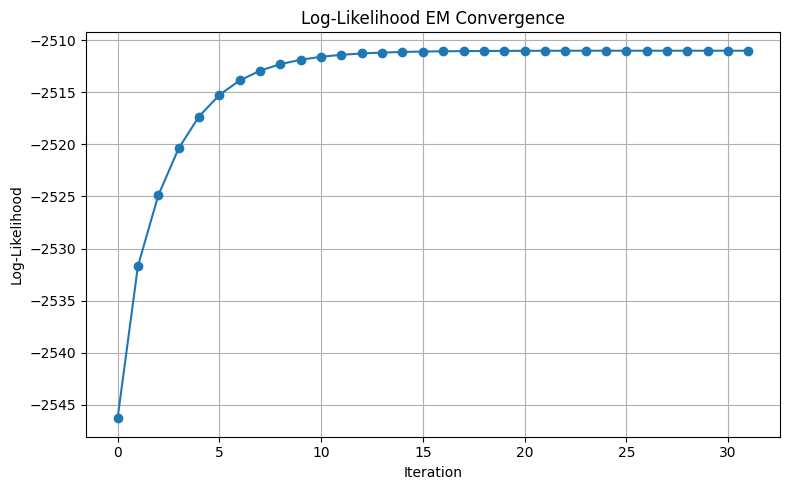


 EM converged in 32 iterations.


In [27]:
# Plot log likelihood convergence of EM
plt.figure(figsize=(8, 5))
plt.plot(log_likelihoods, marker='o', linestyle='-')
plt.title("Log-Likelihood EM Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n EM converged in {len(log_likelihoods)} iterations.")

The smooth, leveling-off curve of Log-Likelihood confirms that the model has found a reasonably stable set of parameters under the Poisson mixture assumption.

In [28]:
# Setup Soft Cluster Assignment of Messages per User - Scatter Plot per iteration 
fig, ax = plt.subplots(figsize=(14, 6))

# Use the first iteration's gamma values to initialize
gamma_init = gamma_history[0]
df_msgs['prob_cluster_1'] = gamma_init[:, 1]

# Create a numeric index for each user to keep the x-axis neat
unique_users = df_msgs['user_id'].unique()
user_to_index = {u: i for i, u in enumerate(unique_users)}
x_numeric = df_msgs['user_id'].map(user_to_index)

# Create an initial scatter plot
scatter = ax.scatter(
    x=x_numeric,
    y=df_msgs['messages'],
    c=df_msgs['prob_cluster_1'],
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    edgecolor='gray'
)

# Fix x/y-limits for consistent scale
ax.set_xlim(-1, len(unique_users) + 1)
ax.set_ylim(0, df_msgs['messages'].max() + 5)
ax.set_title("Messages per User - Soft Cluster Assignment (Iteration 1)")
ax.set_xlabel("User ID Index")
ax.set_ylabel("Messages Sent")
ax.set_xticks(np.arange(len(unique_users)))
ax.set_xticklabels(unique_users, rotation=90)
ax.grid(True)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("P(Power User)")

# Create the update function
def update(frame):
    gamma = gamma_history[frame]
    df_msgs['prob_cluster_1'] = gamma[:, 1]
    scatter.set_array(df_msgs['prob_cluster_1'])
    ax.set_title(f"Messages per User - Soft Cluster Assignment (Iteration {frame + 1})")
    return scatter,

# Create animation for 35 iterations only
anim = animation.FuncAnimation(
    fig, update,
    frames=32,  # Run the animation for 35 iterations only
    interval=200,
    blit=False
)

plt.close(fig)  # Prevent a static plot from being displayed below

# Display the animation
HTML(anim.to_html5_video())


In [29]:
# Setup Histogram Bins Based on Message Counts 
min_val = df_msgs['messages'].min()
max_val = df_msgs['messages'].max()
bins = np.arange(min_val, max_val + 2)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = bins[1] - bins[0]

colors = sns.color_palette("coolwarm", 2)

# Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Use the first iteration's gamma values to compute initial weighted histograms
gamma_init = gamma_history[0]
weights_cluster1 = gamma_init[:, 1]        # weight for Power Users (cluster 1)
weights_cluster0 = 1 - gamma_init[:, 1]      # complementary weight for Light Users (cluster 0)

freq_cluster1, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster1)
freq_cluster0, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster0)

# Create the initial bar plots
bars0 = ax.bar(bin_centers - width/2, freq_cluster0, width=width, color=colors[0],
               alpha=0.7, label='Light Users')
bars1 = ax.bar(bin_centers + width/2, freq_cluster1, width=width, color=colors[1],
               alpha=0.7, label='Power Users')

ax.set_xlabel("Messages Sent per Day")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Message Counts - Soft Cluster Assignment (Iteration 1)")
ax.legend()
ax.grid(True)

# Ensure consistent y-axis limit
y_max = max(max(freq_cluster0), max(freq_cluster1)) * 1.1
ax.set_ylim(0, y_max)

# Define the Update Function for Animation
def update_hist(frame):
    gamma = gamma_history[frame]
    weights_cluster1 = gamma[:, 1]
    weights_cluster0 = 1 - gamma[:, 1]

    # Recompute weighted histograms for the current iteration:
    freq_cluster1, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster1)
    freq_cluster0, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster0)

    # Update heights for the Light Users bars (cluster 0)
    for bar, new_val in zip(bars0, freq_cluster0):
        bar.set_height(new_val)

    # Update heights for the Power Users bars (cluster 1)
    for bar, new_val in zip(bars1, freq_cluster1):
        bar.set_height(new_val)

    # Update the title to reflect the current iteration
    ax.set_title(f"Histogram of Message Counts - Soft Cluster Assignment (Iteration {frame + 1})")
    return bars0 + bars1

# Create the Animation for 35 Iterations
anim_hist = animation.FuncAnimation(
    fig, update_hist,
    frames=32,  # Limit to 35 iterations
    interval=200,
    blit=False
)

plt.close(fig)  # Prevent the static plot from displaying below the animation

# Display the animated histogram as an HTML5 video
HTML(anim_hist.to_html5_video())


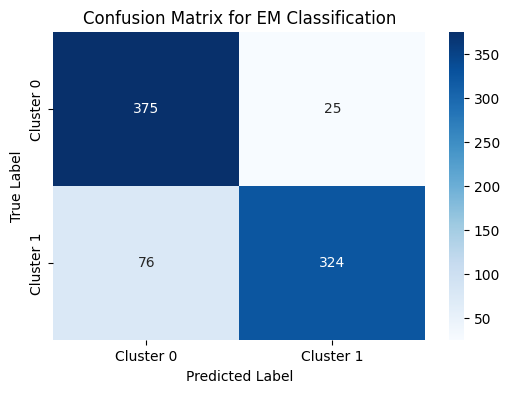

In [30]:
# Setup Confusion Matrix for EM Classification
# Get the predicted labels from the final iteration's gamma values
# We assume that gamma_history[-1] contains the soft assignment probabilities for each data point.
predicted_labels = np.argmax(gamma_history[-1], axis=1)

# True labels from the DataFrame (assuming they are stored in 'true_cluster')
true_labels = df_msgs['true_cluster'].values

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a DataFrame from the confusion matrix
cm_df = pd.DataFrame(cm, index=["Cluster 0", "Cluster 1"], columns=["Cluster 0", "Cluster 1"])

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for EM Classification")
plt.show()


**Takeaways:** The diagonal entries (375 and 324) in the Confusion Matrix suggest that the algorithm is capturing the majority patterns of each group. The misclassifications (25 and 76) are mostly due to overlap or outliers, which is expected in mixture models—especially when there is a moderate overlap in message counts.

Overall, the EM procedure identifies the two latent (hidden) groups quite accurately. The moderate misclassification rate indicates that while most users fall cleanly into one of the two behavioral clusters, a subset hovers between “light” and “power” user behavior, making their assignment ambiguous. Nonetheless, the results confirm that the Poisson mixture model effectively learns and separates users by their messaging activity.

## Part 2: Testing the sensitivity of EM Algorithm to Outliers

Here, we'd like to test how sensitive EM is to outliers, and whether the algorithm is still robust under those conditions.

### Step 2.1: Copy synthetic message data and add more outliers (5% of all data)

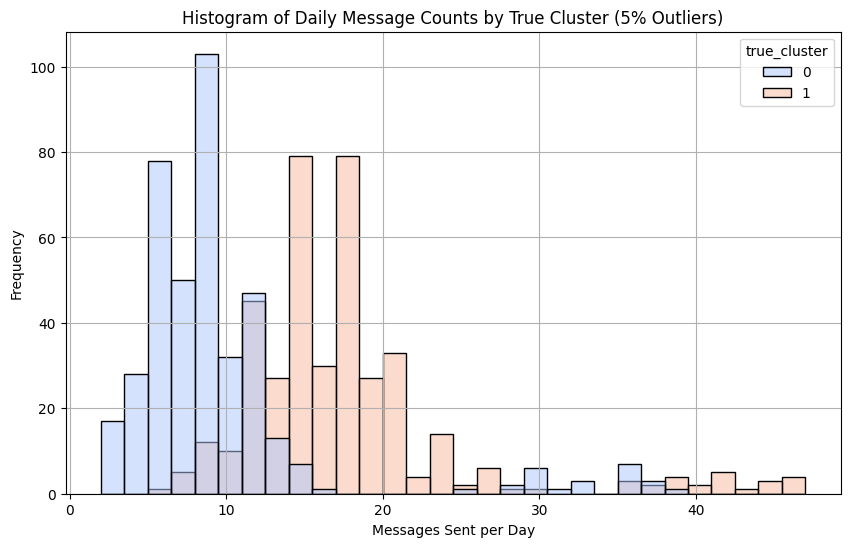

In [31]:
# Make a copy of the original dataframe
df_msgs2 = df_msgs.copy()

np.random.seed(25)

# Add more outliers to the data (5% of all data)
n_outliers2 = int(0.05 * len(df_msgs2))
outlier_indices2 = np.random.choice(df_msgs2.index, size=n_outliers2, replace=False)
df_msgs2.loc[outlier_indices2, 'messages'] += np.random.randint(20, 30, size=n_outliers2)

# Histogram of synthetic data with 5% outliers
plt.figure(figsize=(10, 6))
sns.histplot(data=df_msgs2, x="messages", hue="true_cluster", bins=30, kde=False, palette="coolwarm")
plt.title("Histogram of Daily Message Counts by True Cluster (5% Outliers)")
plt.xlabel("Messages Sent per Day")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

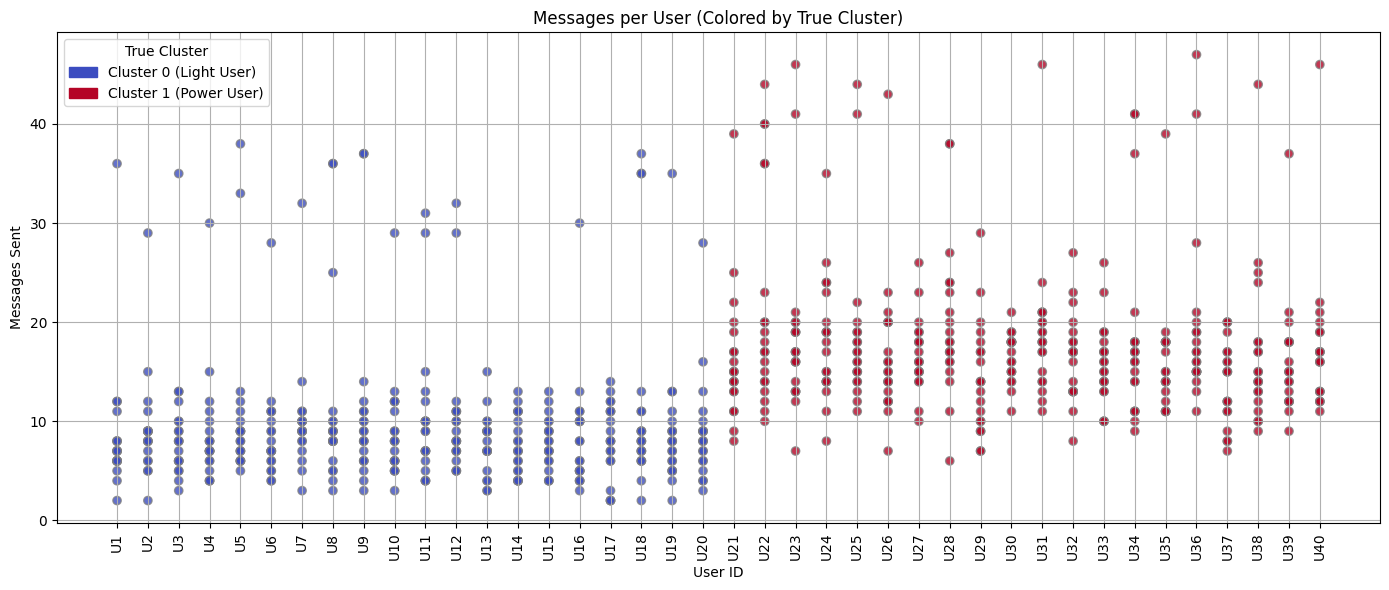

In [32]:
# Scatter plot of synthetic data with 5% outliers
cluster_colors2 = df_msgs2['true_cluster'].map({0: dark_colors[0], 1: dark_colors[1]})

plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    x=df_msgs2['user_id'],
    y=df_msgs2['messages'],  # Each point = messages sent in 1 day by the user
    c=cluster_colors2,
    alpha=0.8,
    edgecolor='gray'
)

plt.xticks(rotation=90)
plt.title("Messages per User (Colored by True Cluster)")
plt.xlabel("User ID")
plt.ylabel("Messages Sent")

legend_handles = [
    Patch(color=dark_colors[0], label='Cluster 0 (Light User)'),
    Patch(color=dark_colors[1], label='Cluster 1 (Power User)')
]
plt.legend(handles=legend_handles, title="True Cluster", loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()


### Step 2.2: Run EM on Synthetic Poisson Message Part 2 Data (More Outliers)

In [33]:
%%capture
# Run EM on the synthetic Poisson message 2 data
data_array2 = df_msgs2["messages"].values
K2 = 2

pi_est2, lambda_est2, gamma2, log_likelihoods2, gamma_history2 = em_poisson_mixture(data_array2, K=K2)

### Step 2.3: Compare Ground Truth and EM Estimates

In [34]:
# Build a DataFrame to compare ground truth and EM estimates for Part 2
comparison_data = {
    "Cluster": [f"Cluster {k}" for k in range(K2)],
    "True λ": [lambda_true[k] for k in range(K2)],
    "Estimated λ": [lambda_est2[k] for k in range(K2)],
    "True π": [pi_true[k] for k in range(K2)],
    "Estimated π": [pi_est2[k] for k in range(K2)]
}

df_comparison = pd.DataFrame(comparison_data)

pd.options.display.float_format = "{:.2f}".format

print("\n=== Ground Truth vs EM Estimates ===")
display(df_comparison)


=== Ground Truth vs EM Estimates ===


,Cluster,True λ,Estimated λ,True π,Estimated π
0,Cluster 0,8,11.38,0.60,0.90
1,Cluster 1,16,31.36,0.40,0.10


**Takeaway:** With more noise injected on to the dataset, we see that the EM Estimates have a very large gap from the ground truth.

### Step 2.4: Visualize EM with Poisson Mixture Models (with more Outliers)

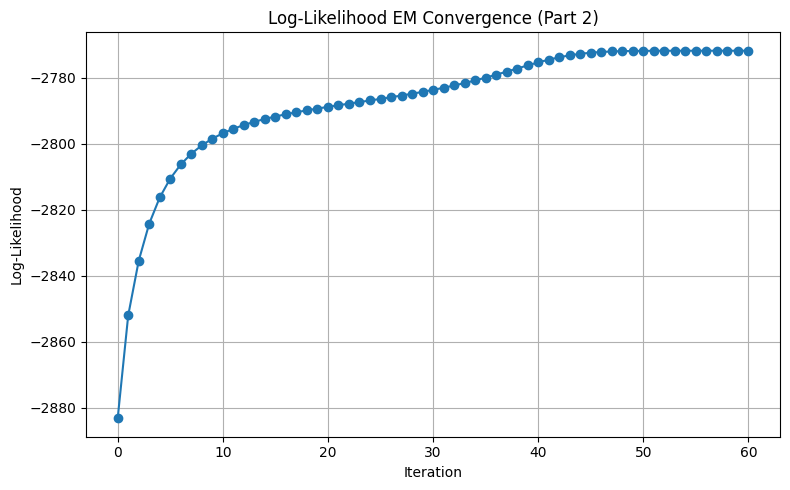


 Part 2: EM converged in 61 iterations.


In [35]:
# Plot log likelihood convergence of EM
plt.figure(figsize=(8, 5))
plt.plot(log_likelihoods2, marker='o', linestyle='-')
plt.title("Log-Likelihood EM Convergence (Part 2)")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n Part 2: EM converged in {len(log_likelihoods2)} iterations.")

**Takeaway:** With outliers making up 5% of the data, EM is significantly less robust, as the algorithm converged to the local maxima at 60+ iterations (versus the original convergence of only 30+ iterations). In a nutshell, it took longer for EM to converge to the optimal with a dataset consisting of more "noise".

In [36]:
# Setup Soft Cluster Assignment of Messages per User - Scatter Plot per iteration 
fig, ax = plt.subplots(figsize=(14, 6))

# Use the first iteration's gamma values from Part 2 to initialize
gamma_init = gamma_history2[0]

# Here, we assume that the second column corresponds to Cluster 1 in Part 2
df_msgs2['prob_cluster_1'] = gamma_init[:, 1]

# Create a numeric index for each user (this ensures consistent ordering on the x-axis)
unique_users = df_msgs2['user_id'].unique()
user_to_index = {u: i for i, u in enumerate(unique_users)}
x_numeric = df_msgs2['user_id'].map(user_to_index)

# Create an initial scatter plot using the Part 2 gamma values
scatter = ax.scatter(
    x=x_numeric,
    y=df_msgs2['messages'],
    c=df_msgs2['prob_cluster_1'],
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    edgecolor='gray'
)

# Fix x/y-limits to keep the chart size consistent throughout the animation
ax.set_xlim(-1, len(unique_users) + 1)
ax.set_ylim(0, df_msgs2['messages'].max() + 5)
ax.set_title("Messages per User - Soft Cluster Assignment (Part 2, Iteration 1)")
ax.set_xlabel("User ID Index")
ax.set_ylabel("Messages Sent")
ax.set_xticks(np.arange(len(unique_users)))
ax.set_xticklabels(unique_users, rotation=90)
ax.grid(True)

# Add a colorbar once and update the label to reflect Part 2
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("P(Power User)")

# Create the update function for the animation
def update(frame):
    gamma = gamma_history2[frame]
    df_msgs2['prob_cluster_1'] = gamma[:, 1]
    scatter.set_array(df_msgs2['prob_cluster_1'])
    ax.set_title(f"Messages per User - Soft Cluster Assignment (Part 2, Iteration {frame + 1})")
    return scatter,

# Create the animation for 35 iterations
anim = animation.FuncAnimation(
    fig, update,
    frames=61,  # Use 35 iterations for the animation
    interval=200,
    blit=False
)

plt.close(fig)  # Prevent a duplicate static plot from displaying

# 9) Display the animation as an HTML5 video in Colab
HTML(anim.to_html5_video())


In [37]:
# Setup Histogram Bins Based on Message Counts
min_val = df_msgs2['messages'].min()
max_val = df_msgs2['messages'].max()
bins = np.arange(min_val, max_val + 2)  # bin edges from minimum to maximum+1
bin_centers = (bins[:-1] + bins[1:]) / 2
width = bins[1] - bins[0]

colors = sns.color_palette("coolwarm", 2)  # colors[0] for Cluster 0, colors[1] for Cluster 1

# Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Use the first iteration's gamma values from Part 2 to compute initial weighted histograms.
gamma_init = gamma_history2[0]
weights_cluster1 = gamma_init[:, 1]        # weight for Cluster 1
weights_cluster0 = 1 - gamma_init[:, 1]      # complementary weight for Cluster 0

freq_cluster1, _ = np.histogram(df_msgs2['messages'], bins=bins, weights=weights_cluster1)
freq_cluster0, _ = np.histogram(df_msgs2['messages'], bins=bins, weights=weights_cluster0)

# Create the initial bar plots
bars0 = ax.bar(bin_centers - width/2, freq_cluster0, width=width, color=colors[0],
               alpha=0.7, label='Cluster 0')
bars1 = ax.bar(bin_centers + width/2, freq_cluster1, width=width, color=colors[1],
               alpha=0.7, label='Cluster 1')

ax.set_xlabel("Messages Sent per Day")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Message Counts - Soft Cluster Assignment (Part 2, Iteration 1)")
ax.legend()
ax.grid(True)

# Ensure a consistent y-axis limit for all frames
y_max = max(max(freq_cluster0), max(freq_cluster1)) * 1.1
ax.set_ylim(0, y_max)

# Define the Update Function for Animation
def update_hist(frame):
    gamma = gamma_history2[frame]
    weights_cluster1 = gamma[:, 1]
    weights_cluster0 = 1 - gamma[:, 1]

    # Recompute weighted histograms for the current iteration:
    freq_cluster1, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster1)
    freq_cluster0, _ = np.histogram(df_msgs['messages'], bins=bins, weights=weights_cluster0)

    # Update heights for the Cluster 0 bars
    for bar, new_val in zip(bars0, freq_cluster0):
        bar.set_height(new_val)

    # Update heights for the Cluster 1 bars
    for bar, new_val in zip(bars1, freq_cluster1):
        bar.set_height(new_val)

    # Update the title to reflect the current iteration.
    ax.set_title(f"Histogram of Message Counts - Soft Cluster Assignment (Part 2, Iteration {frame + 1})")
    return bars0 + bars1

# reate the Animation for 35 Iterations
anim_hist = animation.FuncAnimation(
    fig, update_hist,
    frames=61,  # Run the animation for 35 iterations
    interval=200,
    blit=False
)

plt.close(fig)

# Display the animated histogram as an HTML5 video
HTML(anim_hist.to_html5_video())


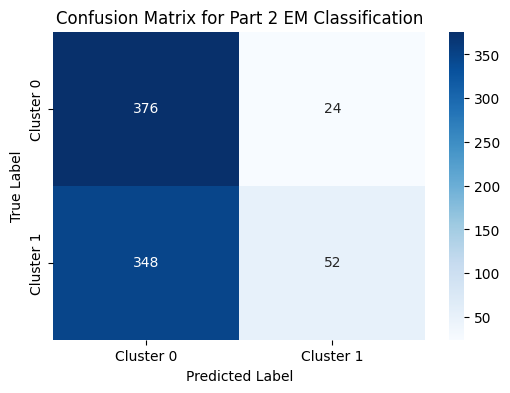

In [38]:
# Setup Confusion Matrix for Part 2
# Convert the final iteration's gamma values for Part 2 into hard labels using argmax
predicted_labels = np.argmax(gamma_history2[-1], axis=1)

# Extract the true labels from the DataFrame
true_labels = df_msgs2['true_cluster'].values

# Compute the confusion matrix:
cm2 = confusion_matrix(true_labels, predicted_labels)

# Create a DataFrame for a prettier display of the confusion matrix:
cm2_df = pd.DataFrame(cm2, index=["Cluster 0", "Cluster 1"], columns=["Cluster 0", "Cluster 1"])

# Plot the confusion matrix using seaborn's heatmap:
plt.figure(figsize=(6, 4))
sns.heatmap(cm2_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Part 2 EM Classification")
plt.show()


Looking at the Part 2 confusion matrix, we see:

- Cluster 0 (True): 376 correct vs. 24 misclassified as Cluster 1
- Cluster 1 (True): Only 52 correct, but 348 misclassified as Cluster 0

This indicates that the EM algorithm heavily biases most observations toward Cluster 0, making Cluster 1 much smaller than it actually is. In other words, a large proportion of “true” Cluster 1 data points end up lumped into Cluster 0.

This result suggests that Part 1’s EM run better captured the distinction between the two clusters, with both clusters gaining relatively high true‐positive counts.


# **Key Takeaways:**

**1. Sensitivity to Data & Initialization:** </br>
The stark difference between Parts 1 and 2 highlights EM’s sensitivity to outliers. In our assignment:

- Part 1 (cleaner data): EM performed well, producing parameter estimates that closely reflected the true clusters.
- Part 2 (more outliers): The introduction of more extreme values skewed the model's estimates, causing it to drift from the ground truth.

This behavior shows that EM assumes data comes from a "nice, well-separated" mixture model. When that assumption is violated—say, by noisy or outlier-heavy data—the algorithm can converge to a local optimum that poorly reflects the true underlying structure.

Also, initialization strategies (like sorted lambdas or quantile-based guesses) and outlier detection/preprocessing are crucial when using EM.

**2. Cluster Separation & Overlap:** </br>
EM is particularly effective when clusters are well-separated — that is, when there's a clear distinction between groups (e.g., light vs. heavy message senders). However:

- In Part 2, the clusters became more overlapping due to outliers or noise.
- This made it harder for EM to assign clear responsibilities (posterior probabilities), leading to misclassification and unstable parameter updates.

When distributions overlap significantly, EM can't confidently distinguish between components — so its "soft" assignments become noisy, and convergence can misrepresent the real structure.

**3. Utility & Limitations:** </br>
Despite its weaknesses, EM remains a powerful tool for discovering latent structure, especially when:

- The underlying generative model is well-approximated by a mixture distribution (e.g., Poisson for count data).
- There's a need for unsupervised learning or modeling incomplete data. 

However, multiple initializations or domain-specific adjustments (e.g., constraints, priors, or different mixture models) can be crucial for achieving more stable, accurate results.